# 02 — Clip-consistent augmentation and the `tf.data` pipeline

**Demonstrates:** why augmenting a clip frame-by-frame would break temporal coherence, how
`safestreets/data/augment.py` draws one transform per clip and replays it across every frame,
a live proof that identical input frames stay identical after the shared draw, a before/after
grid on real cached clips, and the measured throughput of the live `tf.data` pipeline.

**Maps to:** report §4.2 (Albumentations, applied consistently across frames within a clip),
`docs/BUILD_PLAN.md` Phase 3.


In [1]:
import os
import sys
import time
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import numpy as np  # noqa: E402

from safestreets.config import load_config  # noqa: E402
from safestreets.data.augment import (  # noqa: E402
    apply_clip_transform,
    build_eval_transform,
    build_train_transform,
    load_augment_config,
)
from safestreets.data.dataset import load_pipeline_config, make_dataset  # noqa: E402

cfg = load_config()
pipeline_cfg = load_pipeline_config("configs/data.yaml")
augment_cfg = load_augment_config("configs/data.yaml")
pipeline_cfg, augment_cfg


/opt/anaconda3/envs/safestreets/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(PipelineConfig(n_frames=16, height=112, width=112, normalize='unit_range', shuffle_buffer=512, batch_size=8),
 AugmentConfig(horizontal_flip_p=0.5, brightness_contrast_p=0.5, brightness_contrast_limit=0.2, random_resized_crop_p=0.5, random_resized_crop_scale_min=0.8, random_resized_crop_scale_max=1.0, gauss_noise_p=0.3, gauss_noise_std_max=0.08, normalize='unit_range'))

## The problem this module solves

Albumentations applied independently to each frame of a clip draws a *fresh* random transform
per frame: a horizontal flip that fires on frame 3 but not frame 4 flickers the clip rather than
mirroring it, destroying exactly the temporal coherence the LSTM is supposed to model.
`build_train_transform` instead passes every frame into one `A.Compose` call as an
`additional_targets` image, so Albumentations draws each parameter (flip or not, crop box,
brightness delta, noise) once and reuses it for all 16 frames in that single call.

## Live proof: a clip of identical frames stays identical after augmentation

This is the exact property `tests/test_phase03_pipeline.py::test_clip_consistency_identical_frames_stay_identical` checks in the test suite; run live here against a freshly built transform so the notebook demonstrates the property itself, not just a claim that a test exists.

In [2]:
h, w, t = pipeline_cfg.height, pipeline_cfg.width, pipeline_cfg.n_frames
transform = build_train_transform(augment_cfg, h, w, t)
frame = np.random.default_rng(1265).integers(0, 256, size=(h, w, 3), dtype=np.uint8)
clip = np.stack([frame] * t, axis=0)

out = apply_clip_transform(transform, clip)
diverged = [i for i in range(1, pipeline_cfg.n_frames) if not np.array_equal(out[0], out[i])]

assert not diverged, f"frames diverged from frame 0 at indices {diverged}"
print(f"all {pipeline_cfg.n_frames} frames of a constant-input clip stayed pixel-identical "
      "after one shared augmentation draw")


all 16 frames of a constant-input clip stayed pixel-identical after one shared augmentation draw


## Before / after, on real cached clips

`scripts/make_augmented_figure.py` built this grid from the actual Phase 2 train cache: raw frames on top, the same clip's frames after one shared `build_train_transform` draw on the bottom. Flips, crops and brightness shifts move together across the row; nothing flickers frame to frame.

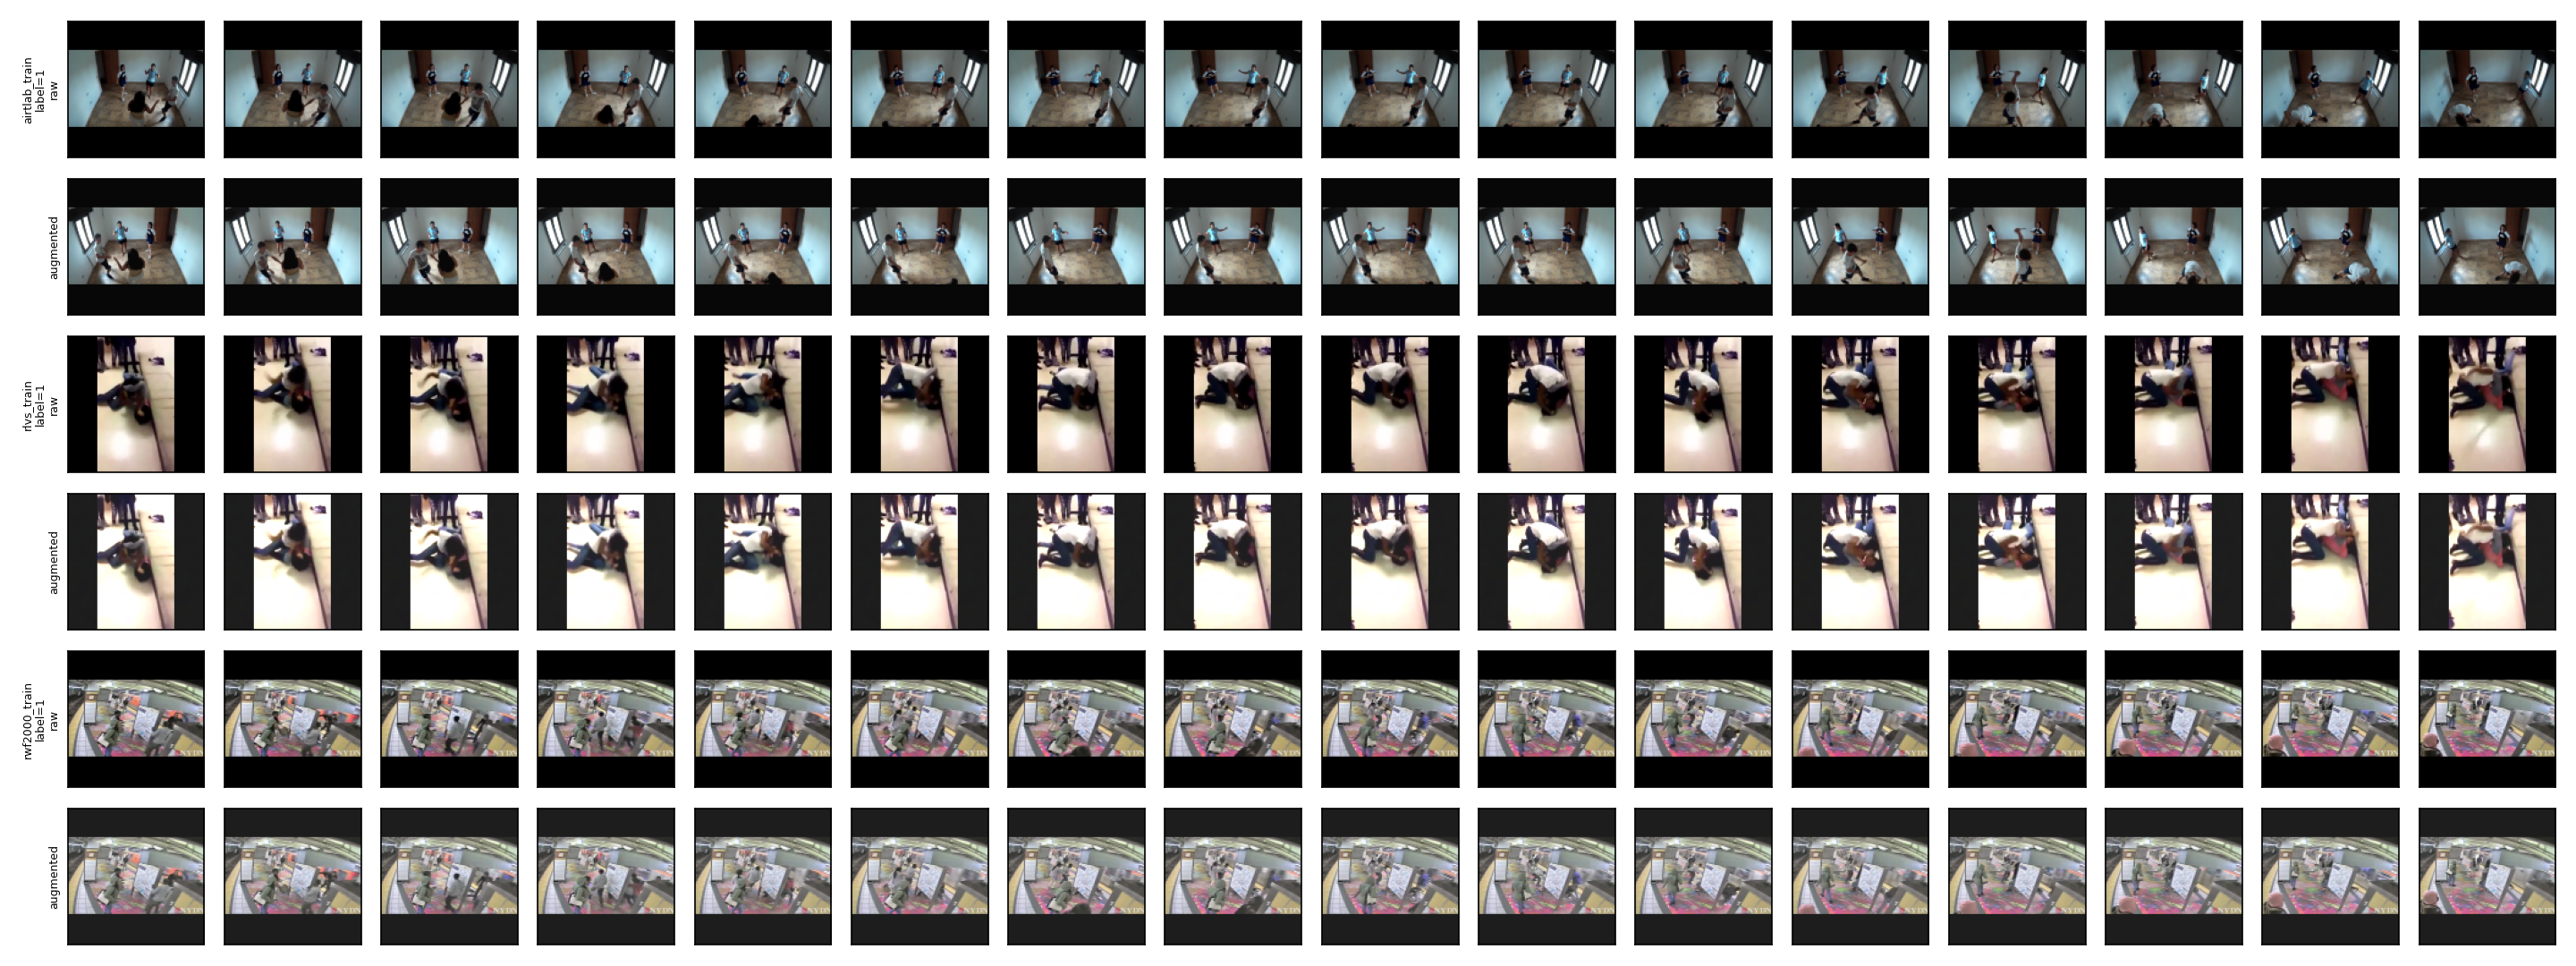

In [3]:
from IPython.display import Image

Image(filename=str(REPO_ROOT / "artifacts" / "figures" / "augmented_clips.png"))


## Throughput of the live `tf.data` pipeline

Measured here, now, on the real train cache (not a synthetic fixture): build the training `tf.data.Dataset` exactly as `safestreets/training/train.py:train_scratch` does, and time how many clips per second it yields.

In [4]:
ds = make_dataset("train", pipeline_cfg, augment_cfg, cfg.cache_dir, training=True, seed=1265)

n_clips = 0
start = time.time()
for clips, _ in ds.take(50):
    n_clips += clips.shape[0]
elapsed = time.time() - start

throughput = n_clips / elapsed
print(f"{n_clips} clips in {elapsed:.2f}s -> {throughput:.1f} clips/s (live measurement, this run)")


2026-10-10 17:08:10.226759: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-10-10 17:08:10.226793: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-10-10 17:08:10.226803: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-10-10 17:08:10.226826: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-10-10 17:08:10.226841: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


400 clips in 1.30s -> 307.3 clips/s (live measurement, this run)


2026-10-10 17:08:11.672860: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Eval transform: deterministic, no randomness

`build_eval_transform` is resize-only and carries no stochastic ops, which is what makes the Sprint 1 feature store (ADR-003) reproducible: it is extracted once, under this transform, never re-drawn.

In [5]:
h, w, t = pipeline_cfg.height, pipeline_cfg.width, pipeline_cfg.n_frames
eval_transform = build_eval_transform(h, w, t)
clip = np.random.default_rng(7).integers(0, 256, size=(t, h, w, 3), dtype=np.uint8)
out1 = apply_clip_transform(eval_transform, clip)
out2 = apply_clip_transform(build_eval_transform(h, w, t), clip)
assert np.array_equal(out1, out2)
print("eval transform is bit-identical across two independently built instances")


eval transform is bit-identical across two independently built instances


## Limitations

- **Augmentation is validated here but not exercised by the production head's training data**
  (ADR-003 option 2): the shipped `lstm_head` trains on precomputed MobileNetV2 features
  extracted under the deterministic eval transform, since a stored feature cannot be
  re-augmented after the backbone's forward pass is baked in. The `scratch` CNN-LSTM comparison
  arm (notebook 03) is the one that trains through this live augmented pipeline end to end.
- The throughput number above is a single live measurement on this machine's current load, not
  an average over repeated runs; treat it as indicative, not a tight benchmark.
